---
title: "Diamonds"
subtitle: "DS 2023 | Communicating with Data"
type: lesson
---


## Overview

**Metadata**

- **name:** Diamonds
- **description:** Physical measurements, gemological grades (the "Four Cs"), and prices for nearly 54,000 round diamonds.
- **provenance:** The `diamonds` dataset from the R **ggplot2** package (Hadley Wickham).
- **format:** long / tidy — 53,940 rows x 10 columns.

**Data dictionary**

:::{table}
| Variable | Data Type | Domain / Range | Description |
|---|---|---|---|
| price | Integer | $326 – $18,823 | Retail price in US dollars. |
| carat | Continuous | 0.2 – 5.01 | Physical weight of the diamond. |
| cut | Categorical (Ordinal) | Fair, Good, Very Good, Premium, Ideal | Quality of the cut, lowest to highest. |
| color | Categorical (Ordinal) | J (worst) to D (best) | Color rating; D is colorless, J is a noticeable tint. |
| clarity | Categorical (Ordinal) | I1 (worst) … IF (best) | Internal flaws / blemishes. |
| x | Continuous | 0 – 10.74 mm | Length in millimetres. |
| y | Continuous | 0 – 58.9 mm | Width in millimetres. |
| z | Continuous | 0 – 31.8 mm | Depth in millimetres. |
| depth | Continuous | 43% – 79% | Total depth percentage: $2z / (x + y)$. |
| table | Continuous | 43% – 95% | Width of the top facet relative to the widest point. |
:::

**Structure**

- **Rows:** 53,940 — one row per diamond.
- **Columns:** 10.
- **Identifiers:** `cut`, `color`, `clarity` (ordinal grades).
- **Measurements:** `carat`, `depth`, `table`, `price`, `x`, `y`, `z`.

**Use cases**

- price regression and multi-variable relationships
- count heatmaps across categorical grades
- large-N distribution and density plots


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML

### Long form (tidy)

No natural key.

In [2]:
diamonds = sns.load_dataset('diamonds')
diamonds.info()
diamonds

<class 'pandas.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
 7   x        53940 non-null  float64 
 8   y        53940 non-null  float64 
 9   z        53940 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.0 MB


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...
53935,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


In [3]:
diamonds['vol'] = diamonds.x * diamonds.y * diamonds.z
diamonds

,carat,cut,color,clarity,depth,table,price,x,y,z,vol
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43,38.202030
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31,34.505856
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31,38.076885
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63,46.724580
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75,51.917250
...,...,...,...,...,...,...,...,...,...,...,...
53935,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50,115.920000
53936,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61,118.110175
53937,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56,114.449728
53938,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74,140.766120


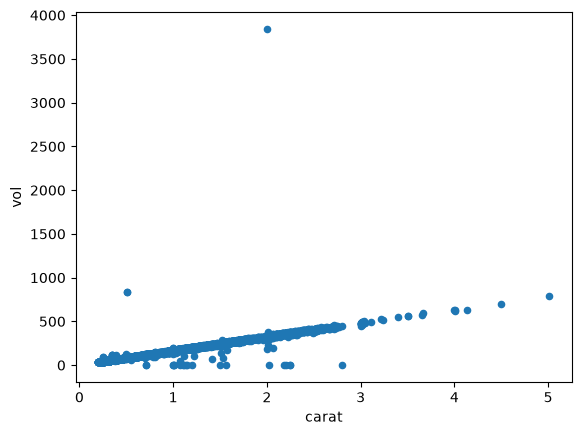

In [4]:
diamonds.plot.scatter('carat','vol')
plt.show()

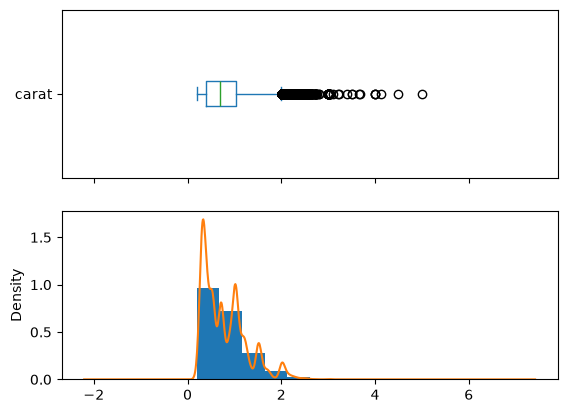

In [5]:
fig, ax = plt.subplots(2, 1, sharex=True)
diamonds.carat.plot.box(vert=False, ax=ax[0])
diamonds.carat.plot.hist(ax=ax[1], density=True)
diamonds.carat.plot.kde(ax=ax[1])
plt.show()

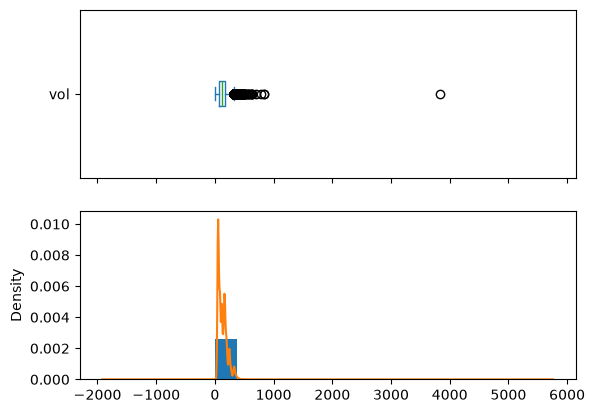

In [15]:
fig, ax = plt.subplots(2, 1, sharex=True)
diamonds.vol.plot.box(vert=False, ax=ax[0])
diamonds.vol.plot.hist(ax=ax[1], density=True)
diamonds.vol.plot.kde(ax=ax[1])
plt.show()

In [16]:
diamonds1a = diamonds.value_counts(['cut', 'clarity']).unstack()
diamonds1a

clarity,IF,VVS1,VVS2,VS1,VS2,SI1,SI2,I1
cut,,,,,,,,
Ideal,1212,2047,2606,3589,5071,4282,2598,146
Premium,230,616,870,1989,3357,3575,2949,205
Very Good,268,789,1235,1775,2591,3240,2100,84
Good,71,186,286,648,978,1560,1081,96
Fair,9,17,69,170,261,408,466,210


In [17]:
diamonds1a.style.background_gradient(axis=None)

clarity,IF,VVS1,VVS2,VS1,VS2,SI1,SI2,I1
cut,,,,,,,,
Ideal,1212,2047,2606,3589,5071,4282,2598,146
Premium,230,616,870,1989,3357,3575,2949,205
Very Good,268,789,1235,1775,2591,3240,2100,84
Good,71,186,286,648,978,1560,1081,96
Fair,9,17,69,170,261,408,466,210


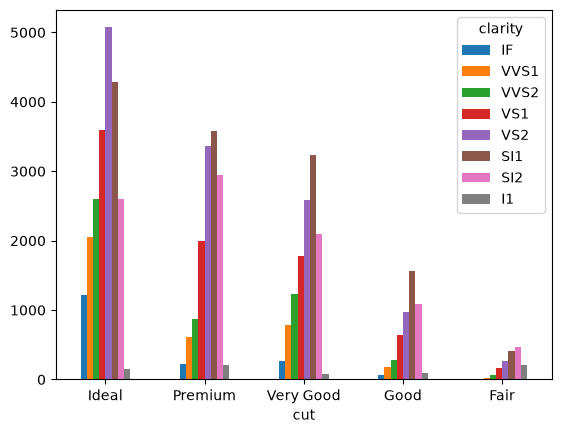

In [25]:
diamonds1a.plot.bar(stacked=False, rot=0)
plt.show()

In [19]:
diamonds1b = diamonds.value_counts(['cut', 'color']).unstack()
diamonds1b

color,D,E,F,G,H,I,J
cut,,,,,,,
Ideal,2834,3903,3826,4884,3115,2093,896
Premium,1603,2337,2331,2924,2360,1428,808
Very Good,1513,2400,2164,2299,1824,1204,678
Good,662,933,909,871,702,522,307
Fair,163,224,312,314,303,175,119


In [20]:
diamonds1b.style.background_gradient(axis=None)

color,D,E,F,G,H,I,J
cut,,,,,,,
Ideal,2834,3903,3826,4884,3115,2093,896
Premium,1603,2337,2331,2924,2360,1428,808
Very Good,1513,2400,2164,2299,1824,1204,678
Good,662,933,909,871,702,522,307
Fair,163,224,312,314,303,175,119


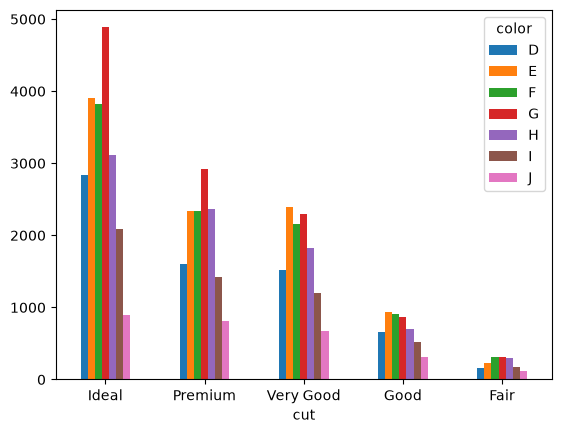

In [26]:
diamonds1b.plot.bar(stacked=False, rot=0)
plt.show()

In [22]:
diamonds1c = diamonds.value_counts(['color', 'clarity']).unstack()
diamonds1c

clarity,IF,VVS1,VVS2,VS1,VS2,SI1,SI2,I1
color,,,,,,,,
D,73,252,553,705,1697,2083,1370,42
E,158,656,991,1281,2470,2426,1713,102
F,385,734,975,1364,2201,2131,1609,143
G,681,999,1443,2148,2347,1976,1548,150
H,299,585,608,1169,1643,2275,1563,162
I,143,355,365,962,1169,1424,912,92
J,51,74,131,542,731,750,479,50


In [23]:
diamonds1c.style.background_gradient(axis=None)

clarity,IF,VVS1,VVS2,VS1,VS2,SI1,SI2,I1
color,,,,,,,,
D,73,252,553,705,1697,2083,1370,42
E,158,656,991,1281,2470,2426,1713,102
F,385,734,975,1364,2201,2131,1609,143
G,681,999,1443,2148,2347,1976,1548,150
H,299,585,608,1169,1643,2275,1563,162
I,143,355,365,962,1169,1424,912,92
J,51,74,131,542,731,750,479,50


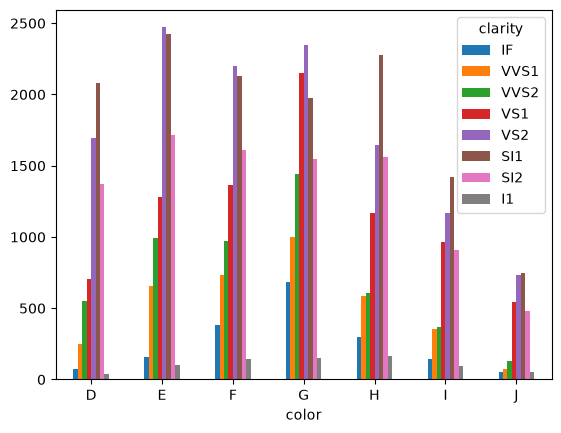

In [27]:
diamonds1c.plot.bar(stacked=False, rot=0)
plt.show()